### 기울기 소실과 기울기 폭발의 원인

In [2]:
import gdown
import zipfile
import os

file_id = "1IadstlphOgnU1LyWSRpZZI30IzVKJQb5"
gdown.download(f"https://drive.google.com/uc?id={file_id}", quiet=False)

zip_path = "/content/ai3.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("ai3")

print(f"압축 해제 완료")

os.chdir("/content/ai3/ch06")

Downloading...
From (original): https://drive.google.com/uc?id=1IadstlphOgnU1LyWSRpZZI30IzVKJQb5
From (redirected): https://drive.google.com/uc?id=1IadstlphOgnU1LyWSRpZZI30IzVKJQb5&confirm=t&uuid=bb2edbbb-9d52-4ea2-9a14-111ab81788a3
To: /content/ai3.zip
100%|██████████| 49.4M/49.4M [00:03<00:00, 13.8MB/s]


압축 해제 완료


In [5]:
# 한글 폰트 (Colab)
import matplotlib.pyplot as plt
!apt-get install -qq fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

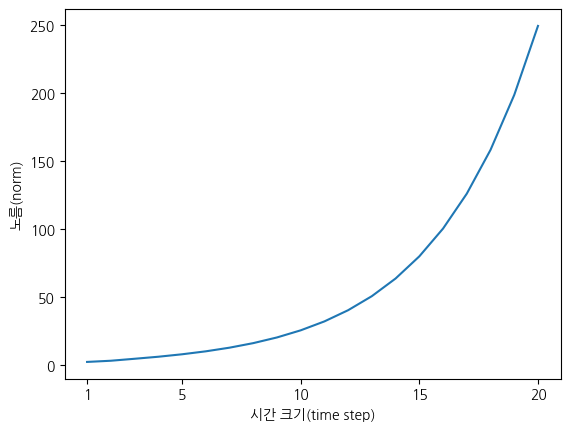

In [6]:
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')

N = 2   # 미니배치 크기
H = 3   # 은닉 상태 벡터의 차원 수
T = 20  # 시계열 데이터의 길이

dh = np.ones((N, H)) # (2,3)

np.random.seed(3) # 재현할 수 있도록 난수의 시드 고정

Wh = np.random.randn(H, H) # (3,3)
# Wh = np.random.randn(H, H) * 0.5
# Wh = np.random.randn(H, H) * 0.7966

norm_list = []
for t in range(T):
    dh = np.dot(dh, Wh.T)   # np.dot(h, wh)
                            # (2,3)(3,3) = (2,3)
    norm = np.sqrt(np.sum(dh**2)) / N
    norm_list.append(norm)

# print(norm_list)

# 그래프 그리기
plt.plot(np.arange(len(norm_list)), norm_list)
plt.xticks([0, 4, 9, 14, 19], [1, 5, 10, 15, 20])
plt.xlabel('시간 크기(time step)')
plt.ylabel('노름(norm)')
plt.show()

### 기울기 폭발 대책

In [ ]:
import numpy as np


dW1 = np.random.rand(3, 3) * 10
dW2 = np.random.rand(3, 3) * 10
grads = [dW1, dW2]
max_norm = 5.0


def clip_grads(grads, max_norm):
    total_norm = 0
    for grad in grads:
        total_norm += np.sum(grad ** 2)
    total_norm = np.sqrt(total_norm)

    print(total_norm)
    rate = max_norm / (total_norm + 1e-6)
    print(rate)
    if rate < 1:
        for grad in grads:
            grad *= rate


print('before:', dW1.flatten())
clip_grads(grads, max_norm)
print('after:', dW1.flatten())